# Native PyTorch Training Loop for Transformers (BERT on MRPC)

This notebook fine-tunes `bert-base-uncased` on the MRPC sentence-pair classification task using a raw PyTorch training loop, without the Hugging Face `Trainer` API.

The experiment is organized into separate training, validation, and final test stages.

**Key Concepts Covered:**
1. **Data Preparation:** Tokenization, dynamic padding, and PyTorch `DataLoader` setup.
2. **Learning Rate Scheduling:** Warmup followed by linear decay.
3. **The Training Loop:** Forward pass, loss computation, backward pass, gradient clipping, optimizer stepping, and scheduler stepping.
4. **Manual Checkpointing:** Saving checkpoints during training and keeping the best validation checkpoint.
5. **Model Selection:** Validation data is used to select the best epoch/checkpoint.
6. **Final Testing:** The saved best model is reloaded and evaluated on a separate held-out test split that was never used for training or checkpoint selection.
7. **Multiple Examples:** The reloaded model is tested on multiple known test examples with ground-truth labels, predictions, correctness, and confidence.

This separation is important: using the same validation set both to select the best checkpoint and to call it the final test result would give an optimistic estimate of generalization. The original MRPC training split is therefore divided into train and validation subsets, while the original MRPC validation split is reserved as the final held-out test set.


## Setup

A fixed random seed is used for reproducibility where possible. Exact results can still vary across GPU, CUDA, PyTorch, and library versions.


In [ ]:
!pip install -q -U datasets huggingface_hub transformers evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.1 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.utils as nn_utils

from datasets import load_dataset
import evaluate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_scheduler
)


Using device: cuda


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")


## Data Preparation

MRPC contains sentence pairs with a binary label indicating whether the two sentences are paraphrases.

The original MRPC `train` split is divided into a training subset and a validation subset. The original MRPC `validation` split is kept untouched until final testing.

This gives three separate roles:

- **Train:** used for gradient updates.
- **Validation:** used for model selection.
- **Test:** used once at the end for the final quantitative result.


In [ ]:
raw_datasets = load_dataset("nyu-mll/glue", "mrpc")
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

train_valid = raw_datasets["train"].train_test_split(
    test_size=0.1,
    seed=seed,
    stratify_by_column="label"
)

raw_train = train_valid["train"]
raw_validation = train_valid["test"]
raw_test = raw_datasets["validation"]

print(f"Training examples: {len(raw_train)}")
print(f"Validation examples: {len(raw_validation)}")
print(f"Final test examples: {len(raw_test)}")


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

mrpc/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.7kB            

mrpc/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training examples: 3301
Validation examples: 367
Final test examples: 408


In [ ]:
tokenized_train = raw_train.map(tokenize_function, batched=True)
tokenized_validation = raw_validation.map(tokenize_function, batched=True)
tokenized_test = raw_test.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def prepare_dataset(dataset):
    dataset = dataset.remove_columns(["sentence1", "sentence2", "idx"])
    dataset = dataset.rename_column("label", "labels")
    dataset.set_format("torch")
    return dataset

tokenized_train = prepare_dataset(tokenized_train)
tokenized_validation = prepare_dataset(tokenized_validation)
tokenized_test = prepare_dataset(tokenized_test)

print(tokenized_train)
print(tokenized_validation)
print(tokenized_test)


Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

Map:   0%|          | 0/367 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3301
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 367
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 408
})


In [ ]:
train_dataloader = DataLoader(
    tokenized_train,
    shuffle=True,
    batch_size=8,
    collate_fn=data_collator
)

validation_dataloader = DataLoader(
    tokenized_validation,
    batch_size=8,
    collate_fn=data_collator
)

test_dataloader = DataLoader(
    tokenized_test,
    batch_size=8,
    collate_fn=data_collator
)

for batch in train_dataloader:
    break

print("Batch Keys and Shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")


Batch Keys and Shapes:
  labels: torch.Size([8])
  input_ids: torch.Size([8, 74])
  token_type_ids: torch.Size([8, 74])
  attention_mask: torch.Size([8, 74])


## Model and Optimizer

The model is initialized from `bert-base-uncased` with a two-class classification head.

The base BERT weights are pretrained, but the MRPC classification head is task-specific and is initialized for this task before fine-tuning.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

model.to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
num_warmup_steps = int(0.1 * num_training_steps)

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print(f"Total training steps: {num_training_steps}")
print(f"Warmup steps: {num_warmup_steps}")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 1239
Warmup steps: 123


## Evaluation Function

The same evaluation function is used for validation and final test evaluation.

It returns loss, accuracy, precision, recall, F1, predictions, labels, and confidence values. The final test set is not passed to this function until model training and checkpoint selection are complete.


In [ ]:
def evaluate_model(model, dataloader):
    model.eval()

    all_predictions = []
    all_labels = []
    all_confidences = []
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            batch_size = batch["labels"].size(0)
            total_loss += outputs.loss.item() * batch_size
            total_examples += batch_size

            probs = torch.softmax(outputs.logits, dim=-1)
            predictions = torch.argmax(probs, dim=-1)
            confidences = torch.max(probs, dim=-1).values

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_confidences = np.array(all_confidences)

    accuracy = accuracy_score(all_labels, all_predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    return {
        "loss": total_loss / total_examples,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predictions": all_predictions,
        "labels": all_labels,
        "confidences": all_confidences
    }


## Native PyTorch Training Loop

The loop explicitly performs:

`forward → loss → backward → gradient clipping → optimizer step → scheduler step → zero gradients`

Validation is performed after every epoch. The best checkpoint is selected using validation F1.

The final test set is not used here. This prevents the test set from influencing model selection.


In [ ]:
progress_bar = tqdm(range(num_training_steps))
max_grad_norm = 1.0
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_f1 = -1.0
best_epoch = 0
global_step = 0
history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_examples = 0

    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        nn_utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        batch_size = batch["labels"].size(0)
        epoch_loss += loss.item() * batch_size
        epoch_examples += batch_size

        global_step += 1
        progress_bar.update(1)

        if global_step % 200 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint-{global_step}")
            model.save_pretrained(checkpoint_path)
            tokenizer.save_pretrained(checkpoint_path)

    train_loss = epoch_loss / epoch_examples
    validation_results = evaluate_model(model, validation_dataloader)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_loss": validation_results["loss"],
        "validation_accuracy": validation_results["accuracy"],
        "validation_precision": validation_results["precision"],
        "validation_recall": validation_results["recall"],
        "validation_f1": validation_results["f1"]
    })

    print(f"Epoch {epoch + 1} finished.")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {validation_results['loss']:.4f}")
    print(f"Validation Accuracy: {validation_results['accuracy']:.4f}")
    print(f"Validation Precision: {validation_results['precision']:.4f}")
    print(f"Validation Recall: {validation_results['recall']:.4f}")
    print(f"Validation F1: {validation_results['f1']:.4f}")

    if validation_results["f1"] > best_f1:
        best_f1 = validation_results["f1"]
        best_epoch = epoch + 1

        best_checkpoint_path = os.path.join(checkpoint_dir, "best_model")
        model.save_pretrained(best_checkpoint_path)
        tokenizer.save_pretrained(best_checkpoint_path)

        print(f"Best checkpoint saved: {best_checkpoint_path}")


  0%|          | 0/1239 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 finished.
Train Loss: 0.5811
Validation Loss: 0.5460
Validation Accuracy: 0.6785
Validation Precision: 0.6796
Validation Recall: 0.9919
Validation F1: 0.8066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3 finished.
Train Loss: 0.2153
Validation Loss: 0.7414
Validation Accuracy: 0.8093
Validation Precision: 0.8504
Validation Recall: 0.8710
Validation F1: 0.8606


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint saved: ./checkpoints/best_model


## Training Curves

The validation metrics are used only for model selection.

The final test metrics are deliberately not plotted here because the test set must remain untouched until the model has been selected.


,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1
0,1,0.5811,0.5460,0.6785,0.6796,0.9919,0.8066
1,2,0.4050,0.5522,0.8038,0.8860,0.8145,0.8487
2,3,0.2153,0.7414,0.8093,0.8504,0.8710,0.8606


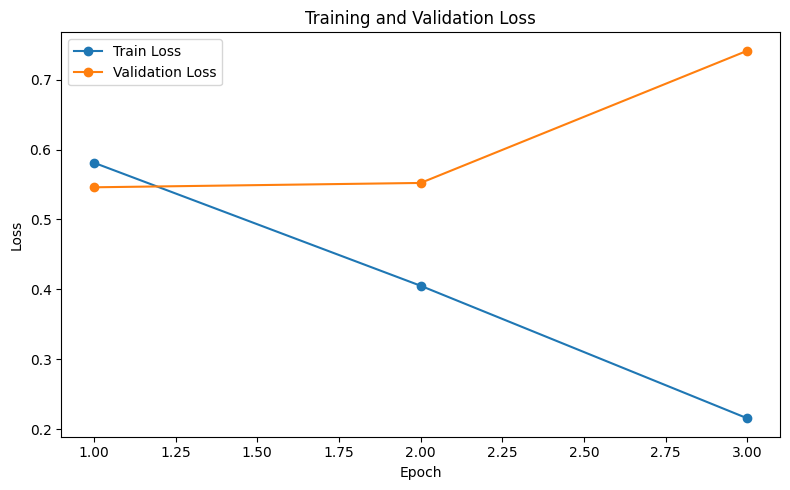

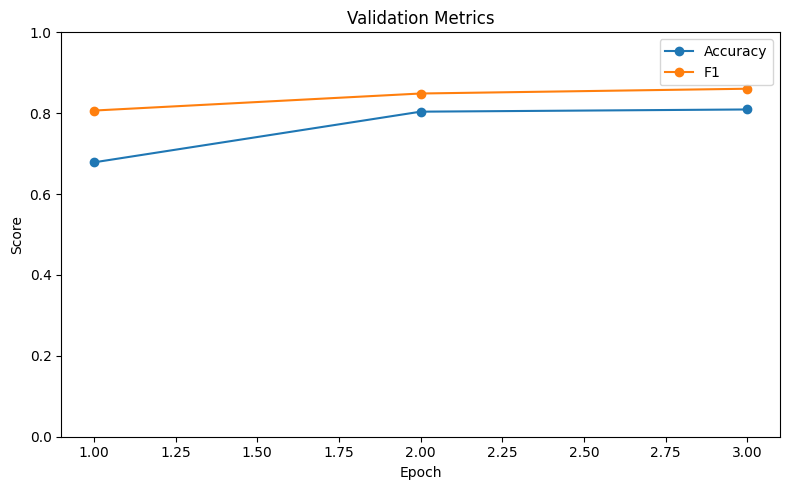

Best validation F1: 0.8606 at epoch 3


In [ ]:
history_df = pd.DataFrame(history)
display(history_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["validation_accuracy"], marker="o", label="Accuracy")
plt.plot(history_df["epoch"], history_df["validation_f1"], marker="o", label="F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best validation F1: {best_f1:.4f} at epoch {best_epoch}")


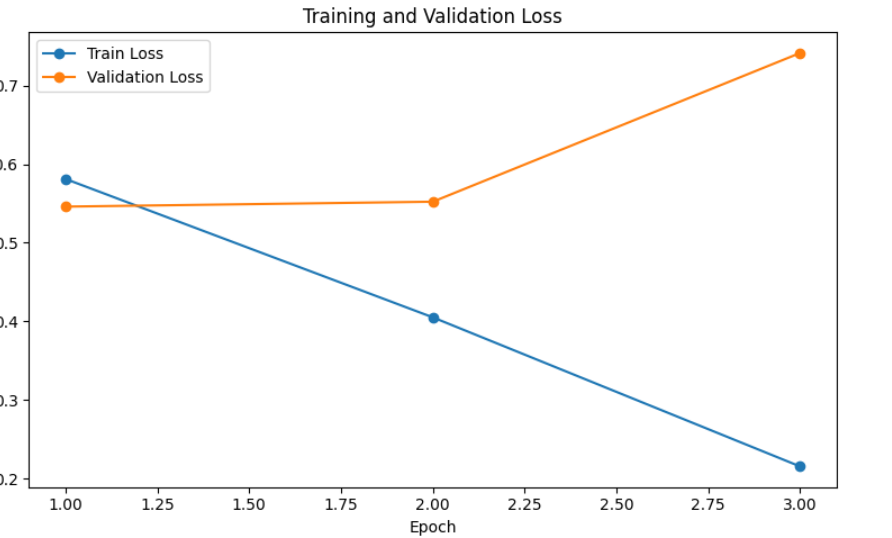

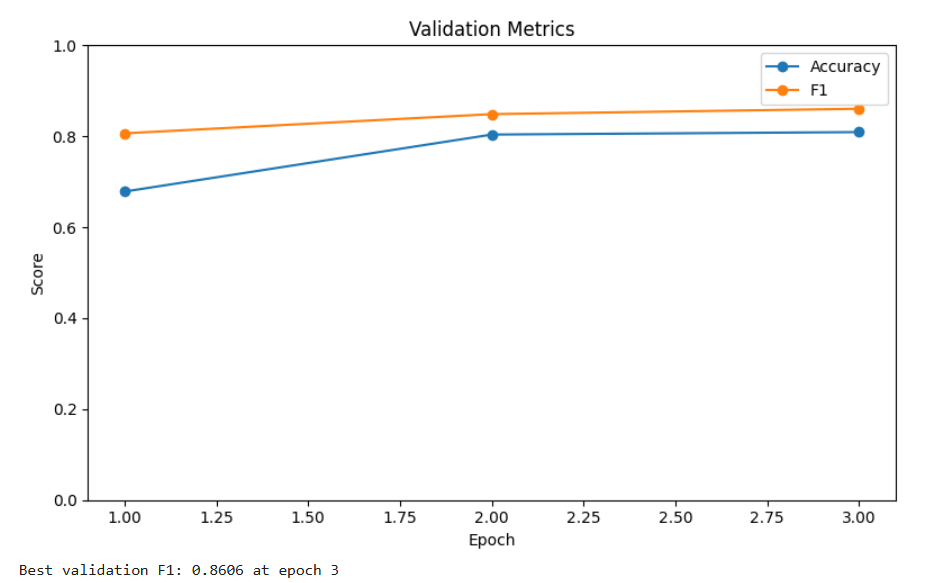

## Load the Trained Model

The best checkpoint is loaded from disk after training.

This verifies that the actual saved artifact, rather than only the in-memory training object, can be restored for independent inference.


In [ ]:
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

best_checkpoint_path = os.path.join(checkpoint_dir, "best_model")

trained_tokenizer = AutoTokenizer.from_pretrained(best_checkpoint_path)
trained_model = AutoModelForSequenceClassification.from_pretrained(best_checkpoint_path)
trained_model.to(device)
trained_model.eval()

print(f"Loaded trained model from: {best_checkpoint_path}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded trained model from: ./checkpoints/best_model


## Final Test on Previously Unused Data

The original MRPC validation split is used here as the final test set.

This data was not used for gradient updates and was not used to select the best epoch. It therefore provides a cleaner estimate of generalization than reporting the validation score used for checkpoint selection.

The test set is evaluated once after the trained model has been reloaded.


In [ ]:
test_results = evaluate_model(trained_model, test_dataloader)

print("\nFinal Test Results:")
print(f"  Accuracy:  {test_results['accuracy']:.4f}")
print(f"  Precision: {test_results['precision']:.4f}")
print(f"  Recall:    {test_results['recall']:.4f}")
print(f"  F1:        {test_results['f1']:.4f}")
print(f"  Test Loss: {test_results['loss']:.4f}")
print(f"  Mean Confidence: {test_results['confidences'].mean():.4f}")



Final Test Results:
  Accuracy:  0.8260
  Precision: 0.8333
  Recall:    0.9319
  F1:        0.8799
  Test Loss: 0.6923
  Mean Confidence: 0.9780


## Test Confusion Matrix

The confusion matrix is calculated from the complete held-out test split.


<Figure size 600x500 with 0 Axes>

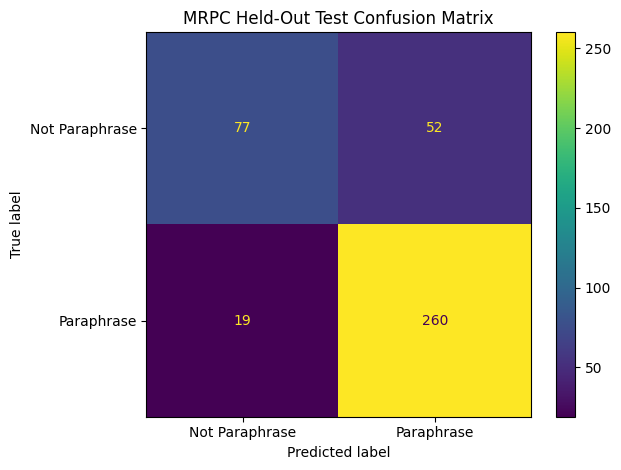

In [ ]:
cm = confusion_matrix(
    test_results["labels"],
    test_results["predictions"]
)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Paraphrase", "Paraphrase"]
)
disp.plot(values_format="d")
plt.title("MRPC Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()


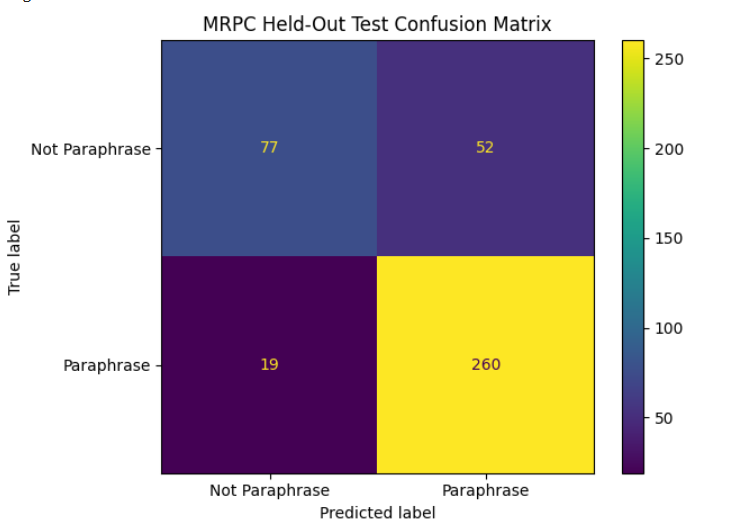

## Multiple Known Test Examples

These examples come from the same held-out test split used for the final quantitative evaluation.

They are shown for direct inspection of the reloaded model. They are not a substitute for the complete test-set metrics.


In [ ]:
example_indices = np.linspace(
    0,
    len(raw_test) - 1,
    num=min(12, len(raw_test)),
    dtype=int
)

example_rows = []

for idx in example_indices:
    example = raw_test[int(idx)]

    inputs = trained_tokenizer(
        example["sentence1"],
        example["sentence2"],
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = trained_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    prediction = int(torch.argmax(probs))
    confidence = float(probs[prediction])

    example_rows.append({
        "Index": int(idx),
        "True Label": int(example["label"]),
        "Predicted Label": prediction,
        "Correct": prediction == int(example["label"]),
        "Confidence": confidence,
        "Sentence 1": example["sentence1"],
        "Sentence 2": example["sentence2"]
    })

examples_df = pd.DataFrame(example_rows)

display(examples_df[[
    "Index",
    "True Label",
    "Predicted Label",
    "Correct",
    "Confidence",
    "Sentence 1",
    "Sentence 2"
]].round({"Confidence": 4}))


,Index,True Label,Predicted Label,Correct,Confidence,Sentence 1,Sentence 2
0,0,1,1,True,0.9959,He said the foodservice pie business doesn 't ...,""" The foodservice pie business does not fit ou..."
1,37,0,0,True,0.9941,The civilian unemployment rate improved margin...,The civilian unemployment rate improved margin...
2,74,1,1,True,0.9937,Carlson on Tuesday said he would not recuse hi...,Service officials said Carlson refused to recu...
3,111,1,1,True,0.9427,Myanmar 's pro-democracy leader Aung San Suu K...,Myanmar 's pro-democracy leader Aung San Suu K...
4,148,1,1,True,0.9133,"Broomhead was assigned to 2nd Squadron , 3rd A...","Broomhead , 34 , was assigned to the 2nd Squad..."
5,185,1,1,True,0.9929,Justice Minister Martin Cauchon and Prime Mini...,Justice Minister Martin Cauchon and Prime Mini...
6,222,1,1,True,0.9957,""" So Sebastian did his best to convincingly co...",""" Sebastian did his best to confess convincing..."
7,259,0,0,True,0.9708,SP2 is basically about security enhancements t...,The firewall in the current Windows XP was kno...
8,296,0,0,True,0.9946,Mr. Kerkorian tried unsuccessfully to take ove...,Kerkorian and Tracinda had also tried to take ...
9,333,1,1,True,0.9914,"The hearing , expected to last a week , will d...",The purpose of the hearing is to determine whe...


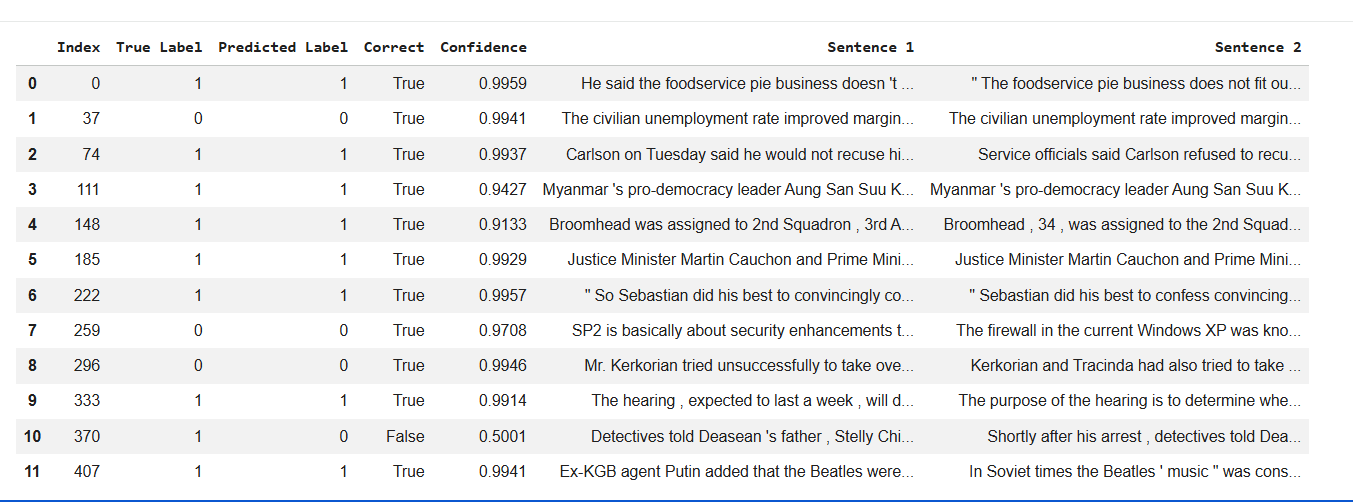

## Final Quantitative Summary

The final performance numbers come from the complete held-out MRPC test split after loading the saved best checkpoint.

The individual examples above are for qualitative inspection only. The test-set metrics are the evidence used for the quantitative conclusion.


In [ ]:
final_summary = pd.DataFrame([{
    "Best Epoch": best_epoch,
    "Test Accuracy": test_results["accuracy"],
    "Test Precision": test_results["precision"],
    "Test Recall": test_results["recall"],
    "Test F1": test_results["f1"],
    "Mean Test Confidence": test_results["confidences"].mean(),
    "Test Examples": len(test_results["labels"])
}])

display(final_summary.round(4))


,Best Epoch,Test Accuracy,Test Precision,Test Recall,Test F1,Mean Test Confidence,Test Examples
0,3,0.826,0.8333,0.9319,0.8799,0.978,408


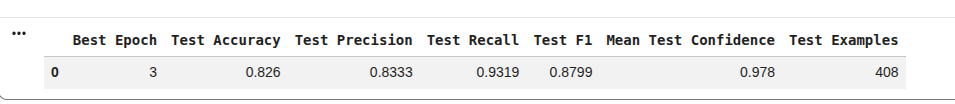

## Conclusion

This notebook demonstrates a complete native PyTorch fine-tuning workflow for BERT on MRPC without using the Hugging Face `Trainer` API.

The experiment now has a clean train/validation/test protocol:

- Training data updates model parameters.
- Validation data selects the best checkpoint.
- The saved best checkpoint is reloaded.
- The previously unused test split is evaluated once.
- Multiple test examples are displayed for direct inspection.
- Accuracy, precision, recall, F1, loss, confidence, and a confusion matrix are calculated from the complete test set.

This is the correct methodology for claiming a final held-out evaluation.

One important terminology point: `bert-base-uncased` is pretrained, but its MRPC classification head is not pretrained for MRPC. The meaningful final model is the fine-tuned checkpoint saved by this notebook. Testing the raw `bert-base-uncased` checkpoint directly as an MRPC classifier would not be a fair baseline because it does not contain a trained MRPC classification head.


In [ ]:
print("Training and final evaluation complete.")
print(f"Best validation F1: {best_f1:.4f}")
print(f"Held-out test accuracy: {test_results['accuracy']:.4f}")
print(f"Held-out test precision: {test_results['precision']:.4f}")
print(f"Held-out test recall: {test_results['recall']:.4f}")
print(f"Held-out test F1: {test_results['f1']:.4f}")


Training and final evaluation complete.
Best validation F1: 0.8606
Held-out test accuracy: 0.8260
Held-out test precision: 0.8333
Held-out test recall: 0.9319
Held-out test F1: 0.8799
